Next up:
> Make recommendations with LLM generated embeddings
> 
> Make recommendations with TFIDF as vectorizer
> 
> Comparison between the 2 methods (Top-N)
> 
> Adding MRR as a metric to evaluate
> 
> Experiment with vote prediction

# 1 LLM Generated Embeddings with Cosine Similarity

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
#  1. load pre-computed data 
print("--- 1. Loading pre-computed embeddings and post data ---")
embeddings_data = np.load('showerthoughts_embeddings.npz')
posts_df = pd.read_csv('reddit_showerthoughts.tsv', sep='\t', on_bad_lines='skip')
posts_df = posts_df.dropna(subset=['title'])
posts_df = posts_df.reset_index(drop=True)

# extract the arrays from the loaded file
post_ids = embeddings_data['ids']
title_embeddings = embeddings_data['title_embed']
content_embeddings = embeddings_data['content_embed']

print(f"Loaded {len(post_ids)} post IDs and their embeddings.")

 1. Loading pre-computed embeddings and post data 
Loaded 95084 post IDs and their embeddings.
------------------------------


In [8]:
# 2. combine title and selftext embeddings
print("\n--- 2. Combining title and selftext embeddings ---")

# weighted average
title_weight = 0.8
content_weight = 0.2
# combined_embeddings = (title_weight * title_embeddings) + (content_weight * content_embeddings)
combined_embeddings = title_embeddings

print(f"Combined embeddings created with shape: {combined_embeddings.shape}")


--- 2. Combining title and selftext embeddings ---
Combined embeddings created with shape: (95084, 768)
------------------------------


In [9]:
# 3. simulate a user and build a user profile

print("\n--- 3. Simulating a user and building their profile ---")

# pick a few posts based on their titles
liked_post_titles = [
    "Muffins are grown up cupcakes",
    "Guns are like night lights for adults",
    "A drug dealer is basically a murderer."
]

# find the indices of these posts in the df
liked_indices = posts_df[posts_df['title'].isin(liked_post_titles)].index.tolist()

if not liked_indices:
    print("Could not find the example liked posts in the dataset. Picking 3 random posts instead.")
    liked_indices = np.random.choice(len(posts_df), 3, replace=False).tolist()

print("Simulated user liked the following posts:")
for idx in liked_indices:
    print(f"  - {posts_df.iloc[idx]['title']}")

# build the user profile by averaging the embeddings of the posts they liked
user_profile_vector = np.mean(combined_embeddings[liked_indices], axis=0)
# reshape for cosine_similarity
user_profile_vector = user_profile_vector.reshape(1, -1)
print(f"\nUser profile vector created with shape: {user_profile_vector.shape}")
print("-" * 30)


--- 3. Simulating a user and building their profile ---
Simulated user liked the following posts:
  - Guns are like night lights for adults
  - A drug dealer is basically a murderer.
  - Muffins are grown up cupcakes

User profile vector created with shape: (1, 768)
------------------------------


In [10]:
# 4. find and rank recommendations
print("\n--- 4. Calculating similarity and finding recommendations ---")
# Use cosine similarity to find the most similar posts
similarity_scores = cosine_similarity(user_profile_vector, combined_embeddings)

similarity_scores = similarity_scores.flatten()

# get the indices of the top N most similar posts
N = 10
# add len(liked_indices) to N because the most similar posts will be the ones the user already liked.
top_n_indices = similarity_scores.argsort()[-(N + len(liked_indices)) :][::-1]

# filter out the posts the user has already seen
recommendation_indices = [idx for idx in top_n_indices if idx not in liked_indices]

print(f"\nTop {N} recommendations for our user:")
for i, idx in enumerate(recommendation_indices[:N]):
    # Get the post title from the original dataframe
    rec_title = posts_df.iloc[idx]['title']
    rec_score = similarity_scores[idx]
    print(f"{i+1}. (Score: {rec_score:.4f}) {rec_title}")


--- 4. Calculating similarity and finding recommendations ---

Top 10 recommendations for our user:
1. (Score: 0.5489) A gun that shoots heroin can have two very different meanings
2. (Score: 0.5316) If you deal drugs, you're a drug dealer
3. (Score: 0.5300) A cupcake is just a muffin in disguise.
4. (Score: 0.5240) Carrying a gun everywhere is the adult version of having a security blanket.
5. (Score: 0.5217) Guns are magic wands that turn people into corpses
6. (Score: 0.5184) Pistols are baby rifles
7. (Score: 0.5159) A pharmacist is literally a drug dealer
8. (Score: 0.5074) Drug dealers go from being monsters to being your best friend as you grow older
9. (Score: 0.4994) Muffins ought to be called breakfast cupcakes
10. (Score: 0.4955) Pharmacists are master drug dealers.


# 2 Content-base System with TFIDF as Vectorizer

In [14]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# 1. load and prepare data
print("--- 1. Loading and preparing post data ---")
try:
    posts_df = pd.read_csv('reddit_showerthoughts.tsv', sep='\t', on_bad_lines='skip')
    posts_df = posts_df.dropna(subset=['title'])
    # combine title and selftext into a single content field for TF-IDF
    # fill any missing selftext with an empty string
    posts_df['content'] = posts_df['title'] + ' ' + posts_df['selftext'].fillna('')
    posts_df = posts_df.reset_index(drop=True)
except FileNotFoundError:
    print("Error: 'reddit_showerthoughts.tsv' not found.")
    exit()

print(f"Loaded and prepared {len(posts_df)} posts.")

--- 1. Loading and preparing post data ---
Loaded and prepared 95084 posts.
------------------------------


In [ ]:
# 2. vectorize content with TF-IDF

print("\n--- 2. Vectorizing text with TF-IDF ---")

tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.95, min_df=2)

# fit the vectorizer to the data and transform the content into a sparse matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(posts_df['content'])

print(f"Created a TF-IDF matrix with shape: {tfidf_matrix.shape}")
print("(This means we have {} posts and {} unique words in our vocabulary)".format(
    tfidf_matrix.shape[0], tfidf_matrix.shape[1]
))


--- 2. Vectorizing text with TF-IDF ---
Created a TF-IDF matrix with shape: (95084, 23234)
(This means we have 95084 posts and 23234 unique words in our vocabulary)
------------------------------


In [ ]:
# 3. simulate a user and build a user profile
# We use the same liked posts as the LLM example for a direct comparison.
print("\n--- 3. Simulating a user and building their profile ---")

# pick a few posts based on their titles
liked_post_titles = [
    "Muffins are grown up cupcakes",
    "Guns are like night lights for adults",
    "A drug dealer is basically a murderer."
]

# find the indices of these posts in our dataframe
liked_indices = posts_df[posts_df['title'].isin(liked_post_titles)].index.tolist()

if not liked_indices:
    print("Could not find the example liked posts in the dataset. Picking 3 random posts instead.")
    liked_indices = np.random.choice(len(posts_df), 3, replace=False).tolist()

print("Simulated user liked the following posts:")
for idx in liked_indices:
    print(f"  - {posts_df.iloc[idx]['title']}")

# build the user profile by averaging the TF-IDF vectors of the posts they liked
# use np.asarray to convert the resulting np.matrix to a standard np.ndarray,
# which is required by the cosine_similarity function.
user_profile_vector = np.asarray(tfidf_matrix[liked_indices].mean(axis=0))
print(f"\nUser profile vector created.")


--- 3. Simulating a user and building their profile ---
Simulated user liked the following posts:
  - Guns are like night lights for adults
  - A drug dealer is basically a murderer.
  - Muffins are grown up cupcakes

User profile vector created.
------------------------------


In [ ]:
# 4. find and rank recommendations
print("\n--- 4. Calculating similarity and finding recommendations ---")
# works efficiently with the sparse matrix from TF-IDF
similarity_scores = cosine_similarity(user_profile_vector, tfidf_matrix)

# flatten it to a 1D array of scores
similarity_scores = similarity_scores.flatten()

# top N most similar posts
N = 10
top_n_indices = similarity_scores.argsort()[-(N + len(liked_indices)) :][::-1]

# filter out the posts the user has already seen
recommendation_indices = [idx for idx in top_n_indices if idx not in liked_indices]

print(f"\nTop {N} recommendations for our user (using TF-IDF):")
for i, idx in enumerate(recommendation_indices[:N]):
    # Get the post title from the original dataframe
    rec_title = posts_df.iloc[idx]['title']
    rec_score = similarity_scores[idx]
    print(f"{i+1}. (Score: {rec_score:.4f}) {rec_title}")


--- 4. Calculating similarity and finding recommendations ---

Top 10 recommendations for our user (using TF-IDF):
1. (Score: 0.3841) Muffins ought to be called breakfast cupcakes
2. (Score: 0.3666) Muffins are to cupcakes as smoothies are to milkshakes
3. (Score: 0.3294) If you deal drugs, you're a drug dealer
4. (Score: 0.3278) If caffeine is a drug then Starbucks is a drug dealer.
5. (Score: 0.3027) A pharmacist is literally a drug dealer
6. (Score: 0.2987) If you kill the murderer, you become the murderer
7. (Score: 0.2932) A 14 year old can find a drug dealer but the police can't.
8. (Score: 0.2877) A pharmacist is a drug dealer with an education
9. (Score: 0.2803) muffins are just unfrosted cake
10. (Score: 0.2792) English Muffins are still called English Muffins in the UK.


# 3 Eval with Voting History - Precision@N, Recall@N, NCDG@N and MRR

[Mean reciprocal rank](https://en.wikipedia.org/wiki/Mean_reciprocal_rank) is a metric used to evaluate the effectiveness of a ranking system, particularly in scenarios where the position of the first relevant result is crucial. It focuses on how quickly a system surfaces the first relevant item in a ranked list of results. MRR is calculated by averaging the reciprocal ranks of the first relevant result for a set of queries. 

Normalized Discounted Cumulative Gain ([NDCG](https://www.evidentlyai.com/ranking-metrics/ndcg-metric)) is a metric that evaluates the quality of recommendation and information retrieval systems. NDCG helps measure a machine learning algorithm's ability to sort items based on relevance. 

In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,ndcg_score
from tqdm import tqdm
import re
from sklearn.metrics import classification_report, roc_auc_score, log_loss, confusion_matrix
import matplotlib.pyplot as plt

In [5]:
print("--- 1. Loading all data ---")

embeddings_data = np.load('showerthoughts_combined_embeddings.npz')
# title_embeddings = embeddings_data['title_embed']
# content_embeddings = embeddings_data['content_embed']
# combined_llm_embeddings = (0.8 * title_embeddings) + (0.2 * content_embeddings)
combined_embeddings = embeddings_data['combined_embed']
embedding_ids=embeddings_data['ids']

# load the posts and votes data
posts_df = pd.read_csv('reddit_showerthoughts.tsv', sep='\t', on_bad_lines='skip').dropna(subset=['title']).reset_index()
votes_df = pd.read_csv('44_million_votes.txt', sep='\t')


print("Data loaded successfully.")
print("-" * 30)

--- 1. Loading all data ---
Data loaded successfully.
------------------------------


In [6]:
print("\n--- 2. Preparing data for evaluation ---")
# define relevant items as upvoted items.
# upvotes_df = votes_df[votes_df['VOTE'] == 'upvote']

# posts_df = posts_df.reset_index(drop=True)
# posts_df.head(5)

posts_df=posts_df[posts_df['submission_id'].isin(embedding_ids)]
# posts_df['embedding_idx'] = posts_df.index
# posts_df.head(5)

# merge votes with posts
posts_df.rename(columns={'submission_id': 'SUBMISSION_ID'}, inplace=True)
merged_df = pd.merge(votes_df, posts_df, on='SUBMISSION_ID')

# select only the top 20 users with the most upvotes
user_vote_counts = merged_df['USERNAME'].value_counts()
# user_vote_counts.head(15)
top_20_users = user_vote_counts.head(20).index.tolist()
eval_df = merged_df[merged_df['USERNAME'].isin(top_20_users)]

print(f"Selected the top {len(top_20_users)} users for evaluation.")
print("-" * 40)
top_20_users


--- 2. Preparing data for evaluation ---
Selected the top 20 users for evaluation.
----------------------------------------


['mguardian_north',
 'Raven2002',
 'Clen23',
 'Reeses2150',
 'spockspeare',
 'apoeticturtle',
 'locks_are_paranoid',
 'Mash404',
 'daygloviking',
 'MingeyMackrel',
 'thx1138jr',
 'Livelogikal',
 'baddonkey',
 'uncertainusurper',
 'lokier01',
 'CubyChris',
 'pierrekrahn',
 'Adventurous_Guy',
 'VerbotenPublish',
 'stratman42']

In [7]:
# 3. evaluation function (NDCG, MRR, Precision, Recall)
def evaluate_recommender(user_item_df, item_features_matrix, top_n=100):
    """
    Performs an offline evaluation using NDCG, MRR, Precision@N and Recall@N.
    Returns average metrics and a dictionary of per-user NDCG scores.
    """
    user_groups = user_item_df.groupby('USERNAME')
    precisions = []
    recalls = []
    reciprocal_ranks = []
    ndcgs = []
    per_user_ndcgs = {} # per-user scores

    print(f"Evaluating for {len(user_groups)} users...")
    for username, group in tqdm(user_groups):
        # split 8:2
        test_size = max(1, int(len(group) * 0.2))
        train_items = group.sample(frac=1, random_state=42).iloc[test_size:]
        test_items = group.sample(frac=1, random_state=42).iloc[:test_size]
        # print(train_items.head(5))

        train_ids = train_items['SUBMISSION_ID'].tolist()
        test_ids = set(test_items['SUBMISSION_ID'].tolist())
        train_indices=[i for i,x in enumerate(embedding_ids) if x in train_ids]
        test_indices=set([i for i,x in enumerate(embedding_ids) if x in test_ids])

        # build user profile from the training items
        user_profile = item_features_matrix[train_indices].mean(axis=0)
        if isinstance(user_profile, np.matrix):
            user_profile = np.asarray(user_profile)
        user_profile = user_profile.reshape(1, -1)

        ################ sort items by timestamp to reveal temporal relavence
        # sort training items by time to calculate weights
        train_items_sorted = train_items.sort_values(by='CREATED_TIME', ascending=True)
        sorted_train_ids = train_items['SUBMISSION_ID'].tolist()
        
        # calculate exponential decay weights
        # decay_rate controls how quickly older items lose importance
        decay_rate = 0.95 
        time_weights = decay_rate ** np.arange(len(train_items_sorted))[::-1]
        
        # get embeddings for sorted training items
        sorted_train_indices=[i for i,x in enumerate(embedding_ids) if x in train_ids]
        item_vectors = item_features_matrix[sorted_train_indices]
        if hasattr(item_vectors, "toarray"):
            item_vectors = item_vectors.toarray()
        
        # create user profile
        user_profile = np.average(item_vectors, axis=0, weights=time_weights)
        user_profile = user_profile.reshape(1, -1)
        ################

        # generate recommendations
        similarity_scores = cosine_similarity(user_profile, item_features_matrix).flatten()
        similarity_scores[train_indices] = -1 # exclude items from training set

        # get ranked indices
        ranked_indices = similarity_scores.argsort()[::-1]
        # print(f"Rank count: {len(ranked_indices)}")
        # print(ranked_indices[:5])

        recommended_indices_top_n = ranked_indices[:top_n]
        
        # precision and recall
        hits = len(set(recommended_indices_top_n) & test_indices)

        # print(f"{hits}/{test_size}")

        precisions.append(hits / top_n)
        recalls.append(hits / len(test_indices))

        # MRR
        rr = 0.0
        for rank, idx in enumerate(ranked_indices):
            if idx in test_indices:
                rr = 1 / (rank + 1)
                break
        reciprocal_ranks.append(rr)
        
        # NDCG
        true_relevance = np.asarray([1 if item_id in test_indices else 0 for item_id in recommended_indices_top_n])
        predicted_scores = similarity_scores[recommended_indices_top_n].reshape(1, -1)
        true_relevance_2d = true_relevance.reshape(1, -1)
        # print(true_relevance_2d)
        # print(predicted_scores)

        user_ndcg_score = ndcg_score(true_relevance_2d, predicted_scores)
        # print(username,user_ndcg_score)
        ndcgs.append(user_ndcg_score)
        per_user_ndcgs[username] = user_ndcg_score


    avg_precision = np.mean(precisions) if precisions else 0
    avg_recall = np.mean(recalls) if recalls else 0
    avg_mrr = np.mean(reciprocal_ranks) if reciprocal_ranks else 0
    avg_ndcg = np.mean(ndcgs) if ndcgs else 0
    
    return (avg_ndcg, avg_mrr, avg_precision, avg_recall), per_user_ndcgs

In [8]:
print("\n--- 4. Running evaluations ---")
TOP_K = 200

# LLM
print(f"\n--- Evaluating LLM Recommender (Top {TOP_K}) ---")
(llm_ndcg, llm_mrr, llm_precision, llm_recall), llm_user_ndcgs = evaluate_recommender(eval_df, combined_embeddings, top_n=TOP_K)
print(f"\nLLM Model Results:")
print(f"  - Average NDCG@{TOP_K}:      {llm_ndcg:.4f}")
print(f"  - Average MRR:              {llm_mrr:.4f}")
print(f"  - Average Precision@{TOP_K}: {llm_precision:.4f}")
print(f"  - Average Recall@{TOP_K}:    {llm_recall:.4f}")

# TF-IDF
print(f"\n--- Evaluating TF-IDF Recommender (Top {TOP_K}) ---")
posts_content = posts_df['title'] + ' ' + posts_df['selftext'].fillna('')
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.95, min_df=2)
tfidf_matrix = tfidf_vectorizer.fit_transform(posts_content)

(tfidf_ndcg, tfidf_mrr, tfidf_precision, tfidf_recall), tfidf_user_ndcgs = evaluate_recommender(eval_df, tfidf_matrix, top_n=TOP_K)
print(f"\nTF-IDF Model Results:")
print(f"  - Average NDCG@{TOP_K}:      {tfidf_ndcg:.4f}")
print(f"  - Average MRR:              {tfidf_mrr:.4f}")
print(f"  - Average Precision@{TOP_K}: {tfidf_precision:.4f}")
print(f"  - Average Recall@{TOP_K}:    {tfidf_recall:.4f}")


--- 4. Running evaluations ---

--- Evaluating LLM Recommender (Top 200) ---
Evaluating for 20 users...


100%|██████████| 20/20 [00:19<00:00,  1.03it/s]



LLM Model Results:
  - Average NDCG@200:      0.1083
  - Average MRR:              0.0569
  - Average Precision@200: 0.0047
  - Average Recall@200:    0.0089

--- Evaluating TF-IDF Recommender (Top 200) ---
Evaluating for 20 users...


100%|██████████| 20/20 [00:13<00:00,  1.48it/s]


TF-IDF Model Results:
  - Average NDCG@200:      0.0798
  - Average MRR:              0.0271
  - Average Precision@200: 0.0033
  - Average Recall@200:    0.0066



--- 5. Generating Per-User NDCG Plot ---


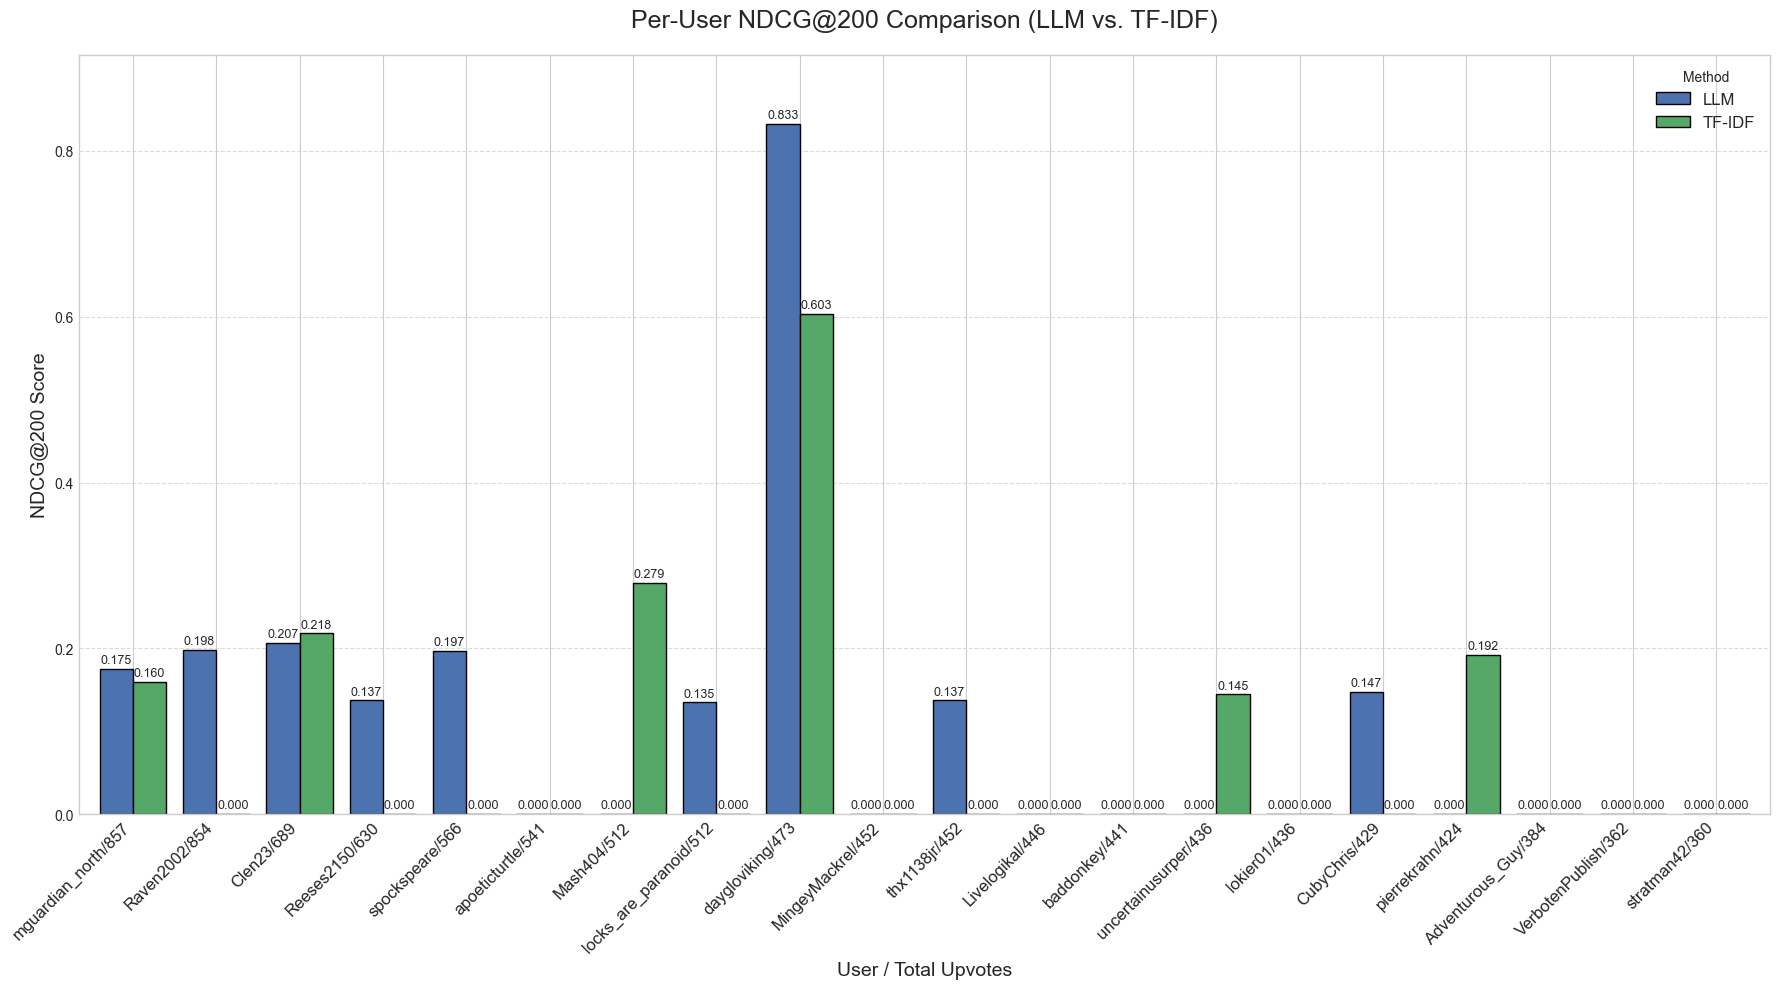

In [10]:
print("\n--- 5. Generating Per-User NDCG Plot ---")

def plot_user_ndcg(llm_scores, tfidf_scores, vote_counts):
    plot_df = pd.DataFrame({'LLM': llm_scores, 'TF-IDF': tfidf_scores})
    
    # vote counts for sorting and labeling
    plot_df = plot_df.join(vote_counts.rename('vote_count'))
    plot_df = plot_df.sort_values(by='vote_count', ascending=False)
    
    # 'username/votecount'
    plot_df['user_label'] = plot_df.index + '/' + plot_df['vote_count'].astype(str)
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(18, 10))
    
    plot_df[['LLM', 'TF-IDF']].plot(kind='bar', ax=ax, width=0.8, 
                                    color=['#4C72B0', '#55A868'],
                                    edgecolor='black')
    
    ax.set_title(f'Per-User NDCG@{TOP_K} Comparison (LLM vs. TF-IDF)', fontsize=18, pad=20)
    ax.set_ylabel(f'NDCG@{TOP_K} Score', fontsize=14)
    ax.set_xlabel('User / Total Upvotes', fontsize=14)
    ax.set_xticklabels(plot_df['user_label'], rotation=45, ha='right', fontsize=12)
    ax.legend(title='Method', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=9, padding=2)
        
    ax.margins(y=0.1)
    plt.tight_layout()
    plt.show()

user_vote_counts.to_csv("vote_count_top20.csv")
pd.Series(index=llm_user_ndcgs.keys(),data=llm_user_ndcgs.values()).to_csv("llm_ndcgs.csv")
pd.Series(index=tfidf_user_ndcgs.keys(),data=tfidf_user_ndcgs.values()).to_csv("tfidf_ndcgs.csv")

plot_user_ndcg(llm_user_ndcgs, tfidf_user_ndcgs, user_vote_counts)


# 4 \[EXPERIMENTAL\] Vote Prediction

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
print("--- 1. Loading all data ---")

embeddings_data = np.load('showerthoughts_combined_embeddings.npz')
# title_embeddings = embeddings_data['title_embed']
# content_embeddings = embeddings_data['content_embed']
# combined_llm_embeddings = (0.6 * title_embeddings) + (0.4 * content_embeddings)
embeddings_text = embeddings_data['combined_embed']
embeddings_subid = embeddings_data['ids']

# embeddings=pd.DataFrame({'SUBMISSION_ID':subid_embeddings,'combined_embed':combined_llm_embeddings})
# combined_llm_embeddings[:10]
# embeddings.head(10)

posts_df = pd.read_csv('reddit_showerthoughts.tsv', sep='\t', on_bad_lines='skip').dropna(subset=['title']).drop(columns=['index'])
votes_df = pd.read_csv('44_million_votes.txt', sep='\t')

print("Data loaded successfully.")
print("-" * 30)

--- 1. Loading all data ---
Data loaded successfully.
------------------------------


In [3]:
# 2. prepare data and select a user
print("\n--- 2. Preparing data and selecting a user ---")
# filter for upvotes and downvotes
votes_df = votes_df[votes_df['VOTE'].isin(['upvote', 'downvote'])]

# create a reliable index for the embedding matrix
# posts_df = posts_df.reset_index(drop=True)
# posts_df['embedding_idx'] = posts_df['submission_id']
# posts_df['embedding_idx']
votes_df = votes_df.reset_index(drop=True)
votes_df['embedding_idx'] = votes_df.index
# votes_df['embedding_idx']
# Merge votes with posts
posts_df.rename(columns={'submission_id': 'SUBMISSION_ID'}, inplace=True)
merged_df = pd.merge(votes_df, posts_df, on='SUBMISSION_ID')

# find a user with a good mix of upvotes and downvotes for a good demonstration
user_vote_counts = merged_df.groupby('USERNAME')['VOTE'].value_counts().unstack().fillna(0)
active_users = user_vote_counts[user_vote_counts['upvote']+user_vote_counts['downvote'] >= 400 ]
if active_users.empty:
    print("Could not find a user with at least 10 upvotes and 10 downvotes.")
    exit()
target_user = active_users.index[0]
user_history = merged_df[merged_df['USERNAME'] == target_user]

print(f"Selected target user: {target_user}")
print(f"User has {len(user_history)} total votes.")
print("-" * 30)
len(active_users)


--- 2. Preparing data and selecting a user ---
Selected target user: Clen23
User has 723 total votes.
------------------------------


17

In [4]:
# 3. split user history and build user profiles
print("\n--- 3. Splitting data and building user taste profiles ---")

# split user history intro training/tesing set
train_df, test_df = train_test_split(user_history, test_size=0.3, random_state=42, stratify=user_history['VOTE'])
embeding_train_indices_num=[i for i,x in enumerate(embeddings_subid) if x in train_df[train_df['VOTE'] == 'upvote']['SUBMISSION_ID'].tolist()+train_df[train_df['VOTE'] == 'downvote']['SUBMISSION_ID'].tolist()]
train_df=train_df[train_df['SUBMISSION_ID'].isin(embeddings_subid[embeding_train_indices_num])]
embeding_test_indices_num=[i for i,x in enumerate(embeddings_subid) if x in test_df[test_df['VOTE'] == 'upvote']['SUBMISSION_ID'].tolist()+test_df[test_df['VOTE'] == 'downvote']['SUBMISSION_ID'].tolist()]
test_df=test_df[test_df['SUBMISSION_ID'].isin(embeddings_subid[embeding_test_indices_num])]

# train_df[:10]
# len(train_df)

# separate the user's training history into upvoted and downvoted posts
upvoted_train_indices = train_df[train_df['VOTE'] == 'upvote']['SUBMISSION_ID'].tolist()
# upvoted_train_indices=[x for x in upvoted_train_indices if x in embeddings_subid[embeding_indices_num]]
downvoted_train_indices = train_df[train_df['VOTE'] == 'downvote']['SUBMISSION_ID'].tolist()
# downvoted_train_indices=[x for x in downvoted_train_indices if x in embeddings_subid[embeding_indices_num]]
# test_df
upvoted_test_indices = test_df[test_df['VOTE'] == 'upvote']['SUBMISSION_ID'].tolist()
# upvoted_test_indices=[x for x in upvoted_test_indices if x in embeddings_subid[embeding_indices_num]]
downvoted_test_indices = test_df[test_df['VOTE'] == 'downvote']['SUBMISSION_ID'].tolist()
# downvoted_test_indices=[x for x in downvoted_test_indices if x in embeddings_subid[embeding_indices_num]]

# downvoted_train_indices

embedings_upvoted_train_indices=[i for i,x in enumerate(embeddings_subid) if x in upvoted_train_indices]
embedings_downvoted_train_indices=[i for i,x in enumerate(embeddings_subid) if x in downvoted_train_indices]


# create two taste profiles: one for what they like, one for what they dislike
upvote_profile = embeddings_text[embedings_upvoted_train_indices].mean(axis=0).reshape(1, -1)
downvote_profile = embeddings_text[embedings_downvoted_train_indices].mean(axis=0).reshape(1, -1)

print("Successfully built 'upvote' and 'downvote' profiles for the user.")
print("-" * 30)
len(test_df)


--- 3. Splitting data and building user taste profiles ---
Successfully built 'upvote' and 'downvote' profiles for the user.
------------------------------


208

In [5]:
# 4. create feature set for the classifier
print("\n--- 4. Creating features for the classifier ---")
def create_features(item_indices, up_profile, down_profile, embeddings):
    """Calculates similarity features for a set of items."""
    item_vectors = embeddings[item_indices]
    
    # feat 1: Similarity to what the user likes
    sim_to_upvotes = cosine_similarity(item_vectors, up_profile).flatten()
    
    # feat 2: Similarity to what the user dislikes
    sim_to_downvotes = cosine_similarity(item_vectors, down_profile).flatten()
    
    # Combine into a feature matrix
    return np.vstack([sim_to_upvotes, sim_to_downvotes]).T

# Create features for the training set
X_train = create_features(embeding_train_indices_num, upvote_profile, downvote_profile, embeddings_text)
y_train = (train_df['VOTE'] == 'upvote').astype(int) # Target: 1 for upvote, 0 for downvote
# y_train = train_df[train_df['VOTE'] == 'upvote']['VOTE'].tolist()  # Target: 1 for upvote, 0 for downvote
# train_indices_numerical=[i for i,_ in enumerate(train_df['VOTE']) if train_df.iloc[i]['SUBMISSION_ID'] in upvoted_train_indices+downvoted_train_indices]
# y_train=[1 if x in train_df['VOTE'] else 0 for i,x in enumerate(train_df[]['VOTE'])]
# numerical_indices[:10]


# create features for the test set
# embeding_indices_num=[i for i,x in enumerate(embeddings_subid) if x in upvoted_test_indices+downvoted_test_indices]
X_test = create_features(embeding_test_indices_num, upvote_profile, downvote_profile, embeddings_text)
y_test = (test_df['VOTE'] == 'upvote').astype(int)

print(f"Created training features with shape: {X_train.shape}")
print(f"Created test features with shape: {X_test.shape}")
print("-" * 30)


--- 4. Creating features for the classifier ---
Created training features with shape: (481, 2)
Created test features with shape: (208, 2)
------------------------------


In [6]:
# 5. train classifier and make predictions
print("\n--- 5. Training model and making predictions ---")
# train a simple but effective Logistic Regression model
classifier = LogisticRegression(random_state=42, class_weight='balanced')
classifier.fit(X_train, y_train)

# make predictions on the test set
predictions = classifier.predict(X_test)
prediction_probs = classifier.predict_proba(X_test)[:, 1] # probability of upvote

print("Model trained. Predictions made on the test set.")
print("-" * 30)


--- 5. Training model and making predictions ---
Model trained. Predictions made on the test set.
------------------------------


In [7]:
# 6. display results
print("\n--- 6. Prediction Results ---")
# add predictions to the test dataframe for easy viewing
test_df['predicted_vote'] = ['upvote' if p == 1 else 'downvote' for p in predictions]
test_df['upvote_probability'] = prediction_probs

# display a sample of the results
print("Sample of predictions vs actual votes:")
for _, row in test_df.iterrows():
    print(f"\nPost: '{row['title']}'")
    print(f"  - Prediction: {row['predicted_vote']} (Prob: {row['upvote_probability']:.2f})")
    print(f"  - Actual Vote: {row['VOTE']}")

# print a full classification report
print("\n\n--- Overall Model Performance ---")
print(classification_report(y_test, predictions, target_names=['downvote', 'upvote']))


--- 6. Prediction Results ---
Sample of predictions vs actual votes:

Post: 'The more attractive you are, the less your farts define you'
  - Prediction: upvote (Prob: 0.51)
  - Actual Vote: downvote

Post: 'People say vaping is gay but use straws to drink.'
  - Prediction: downvote (Prob: 0.49)
  - Actual Vote: downvote

Post: 'You have 2-4 minutes to live but every time you breath it resets'
  - Prediction: downvote (Prob: 0.48)
  - Actual Vote: downvote

Post: 'In some fictions, ghosts are depicted as floating, which implies they're not affected by gravity. Therefore, it's very likely they actively need to keep up with the Earth's trajectory and rotation.'
  - Prediction: upvote (Prob: 0.51)
  - Actual Vote: upvote

Post: 'Fear and Bear dont rhyme'
  - Prediction: downvote (Prob: 0.47)
  - Actual Vote: downvote

Post: 'The average color of the universe is getting darker as more and more people switch to dark mode.'
  - Prediction: upvote (Prob: 0.53)
  - Actual Vote: downvote

Post

In [10]:
# 6. display results elaborate
print("\n--- 6. Prediction Results ---")
# add predictions to the test dataframe for easy viewing
test_df['predicted_vote'] = ['upvote' if p == 1 else 'downvote' for p in predictions]
test_df['upvote_probability'] = prediction_probs

# display a sample of the results
print("Sample of predictions vs actual votes:")
for _, row in test_df.head(5).iterrows():
    print(f"\nPost: '{row['title']}'")
    print(f"  - Prediction: {row['predicted_vote']} (Prob: {row['upvote_probability']:.2f})")
    print(f"  - Actual Vote: {row['VOTE']}")

print("\n\n--- Overall Model Performance ---")

# classification Report (Precision, Recall, F1)
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=['downvote', 'upvote']))

# AUC Score
auc_score = roc_auc_score(y_test, prediction_probs)
print(f"\nAUC Score: {auc_score:.4f}")
print("(Measures ability to distinguish between classes. 1.0 is perfect, 0.5 is random.)")

# log Loss
log_loss_score = log_loss(y_test, prediction_probs)
print(f"\nLog Loss: {log_loss_score:.4f}")
print("(Measures the quality of probabilities. Lower is better.)")

# confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
print("\nConfusion Matrix:")
print(f"                 Predicted Downvote | Predicted Upvote")
print(f"Actual Downvote: {tn:^20} | {fp:^18}")
print(f"Actual Upvote:   {fn:^20} | {tp:^18}")


--- 6. Prediction Results ---
Sample of predictions vs actual votes:

Post: 'The more attractive you are, the less your farts define you'
  - Prediction: upvote (Prob: 0.51)
  - Actual Vote: downvote

Post: 'People say vaping is gay but use straws to drink.'
  - Prediction: downvote (Prob: 0.49)
  - Actual Vote: downvote

Post: 'You have 2-4 minutes to live but every time you breath it resets'
  - Prediction: downvote (Prob: 0.48)
  - Actual Vote: downvote

Post: 'In some fictions, ghosts are depicted as floating, which implies they're not affected by gravity. Therefore, it's very likely they actively need to keep up with the Earth's trajectory and rotation.'
  - Prediction: upvote (Prob: 0.51)
  - Actual Vote: upvote

Post: 'Fear and Bear dont rhyme'
  - Prediction: downvote (Prob: 0.47)
  - Actual Vote: downvote


--- Overall Model Performance ---

Classification Report:
              precision    recall  f1-score   support

    downvote       0.85      0.62      0.72       171
    